In [2]:
# Exploratory Data Analysis and Initial Preprocessing
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from src.data_loader import load_data
from src.preprocessing import handle_missing_values

In [3]:
# Load data
data = pd.read_csv(r'C:\Users\paral\Documents\Customer Segmentation and Trageted Marketing for Telecom Operator\Data\data_telecom.csv')

In [4]:
# Displaying basic info
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Mobile_Number            200000 non-null  int64  
 1   MAINACTBAL               200000 non-null  float64
 2   LASTVCEUSGDATE           199981 non-null  object 
 3   LASTRECHRGDATE           199852 non-null  object 
 4   FIRSTCALLDATE            199981 non-null  object 
 5   DEVICETYPE               200000 non-null  object 
 6   ISDEVICE3GENABLED        200000 non-null  object 
 7   VASSUBSCRIBERFLAG        200000 non-null  object 
 8   ISDEVICEDATAENABLED      200000 non-null  object 
 9   AGEONNETWORK             200000 non-null  float64
 10  LASTREVGENEVTDATE        200000 non-null  object 
 11  SUBSRIBERLASTBALANCE     200000 non-null  float64
 12  last_app_used            79836 non-null   object 
 13  CUSTSEGMENT              51917 non-null   object 
 14  CNTC

,Mobile_Number,MAINACTBAL,LASTVCEUSGDATE,LASTRECHRGDATE,FIRSTCALLDATE,DEVICETYPE,ISDEVICE3GENABLED,VASSUBSCRIBERFLAG,ISDEVICEDATAENABLED,AGEONNETWORK,...,SUMVCEREVCD1_30,SUMDATAREVCD1_30,SUMDATAUSGCD1_30,SUMVOICEUSGCD1_30,SUMDATAUSG4GCD1_15,SUMDATAUSG4GCD15_30,SMARTPHONEFLAG,MAINACTBAL1,CNTZEROBALCD_1,FIRSTREVGENEVTDATE
0,61159748,0.2630,04/16/2023 00:00:00,04/08/2023 00:00:00,04/14/2022 00:00:00,Smartphone,Y,N,Y,368.0,...,22.985625,0.00000,1.133457e+10,12878.0,275794501.0,1.105682e+10,Y,0.26304,0,04/14/2022 00:00:00
1,17488035,0.1901,04/15/2023 00:00:00,03/26/2023 00:00:00,06/13/2007 00:00:00,Smartphone,Y,N,Y,5786.0,...,26.570050,0.00000,0.000000e+00,652.0,0.0,0.000000e+00,Y,0.19011,0,06/14/2007 00:00:00
2,43749562,0.1243,04/01/2023 00:00:00,01/31/2023 00:00:00,02/16/2022 00:00:00,Voice Centric,N,N,N,425.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,0.12430,0,02/16/2022 00:00:00
3,87451055,1.6096,04/16/2023 00:00:00,04/11/2023 00:00:00,06/29/2013 00:00:00,Smartphone,Y,N,Y,3570.0,...,30.480910,0.52052,4.288550e+05,2721.0,426609.0,2.246000e+03,Y,1.60957,0,07/08/2013 00:00:00
4,64576359,5.1838,04/16/2023 00:00:00,04/10/2023 00:00:00,04/30/2012 00:00:00,Voice Centric,N,N,N,3999.0,...,95.027229,0.00000,0.000000e+00,3123.0,0.0,0.000000e+00,N,5.18376,0,05/05/2012 00:00:00


In [5]:
# Check for missing values
data.isnull().sum()

Mobile_Number                   0
MAINACTBAL                      0
LASTVCEUSGDATE                 19
LASTRECHRGDATE                148
FIRSTCALLDATE                  19
DEVICETYPE                      0
ISDEVICE3GENABLED               0
VASSUBSCRIBERFLAG               0
ISDEVICEDATAENABLED             0
AGEONNETWORK                    0
LASTREVGENEVTDATE               0
SUBSRIBERLASTBALANCE            0
last_app_used              120164
CUSTSEGMENT                148083
CNTCHURND1_30              110863
HANDSETCHANGESFLAGD1_30    164493
DEVICENETWORK               78356
DEVICEMODELC                78356
DEVICEDUALSIMFLAG           78356
ARPUD1_30                       0
SUMVCEREVCD1_30             45119
SUMDATAREVCD1_30            48283
SUMDATAUSGCD1_30            44858
SUMVOICEUSGCD1_30           44858
SUMDATAUSG4GCD1_15          50208
SUMDATAUSG4GCD15_30         47992
SMARTPHONEFLAG                  0
MAINACTBAL1                     0
CNTZEROBALCD_1                  0
FIRSTREVGENEVT

In [6]:
# Statistical summary
data.describe()

,Mobile_Number,MAINACTBAL,AGEONNETWORK,SUBSRIBERLASTBALANCE,CNTCHURND1_30,HANDSETCHANGESFLAGD1_30,DEVICEDUALSIMFLAG,ARPUD1_30,SUMVCEREVCD1_30,SUMDATAREVCD1_30,SUMDATAUSGCD1_30,SUMVOICEUSGCD1_30,SUMDATAUSG4GCD1_15,SUMDATAUSG4GCD15_30,MAINACTBAL1,CNTZEROBALCD_1
count,2.000000e+05,200000.000000,200000.000000,200000.000000,89137.000000,35507.000000,121644.00000,200000.000000,154881.000000,151717.000000,1.551420e+05,155142.000000,1.497920e+05,1.520080e+05,200000.000000,200000.000000
mean,4.543535e+07,11.007088,1993.406405,11.007088,1.843398,1.364942,1.99649,176.082796,43.608401,2.491229,4.339707e+09,7641.116912,1.875771e+09,2.041547e+09,11.007088,0.003020
std,2.900110e+07,48.991782,1774.404666,48.991782,1.031201,0.789854,0.44538,297.788781,87.563824,6.910859,1.172820e+10,13910.996894,5.541364e+09,5.982678e+09,48.991782,0.054872
min,2.435000e+03,0.000000,101.000000,0.000000,1.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,2.015619e+07,0.008600,531.000000,0.008600,1.000000,1.000000,2.00000,0.000000,0.000000,0.000000,0.000000e+00,435.000000,0.000000e+00,0.000000e+00,0.008610,0.000000
50%,4.208031e+07,0.141900,1369.000000,0.141900,2.000000,1.000000,2.00000,58.000000,9.217591,0.000000,1.327200e+04,2573.000000,0.000000e+00,0.000000e+00,0.141880,0.000000
75%,6.797840e+07,8.298200,3129.000000,8.298200,2.000000,2.000000,2.00000,216.000000,50.621675,0.455455,1.666354e+09,8977.750000,9.751026e+07,1.794456e+08,8.298160,0.000000
max,9.998810e+07,4909.386900,6638.000000,4909.386900,8.000000,30.000000,6.00000,9251.000000,5313.730175,225.059835,2.380753e+11,666309.000000,1.588541e+11,1.048388e+11,4909.386700,1.000000


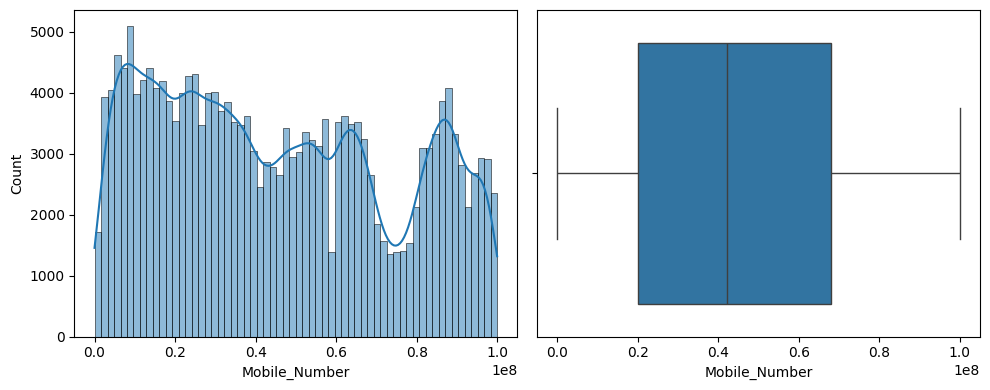

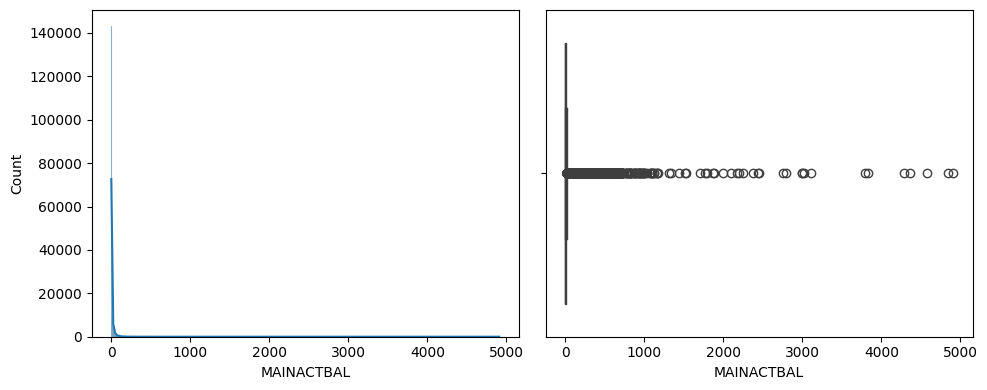

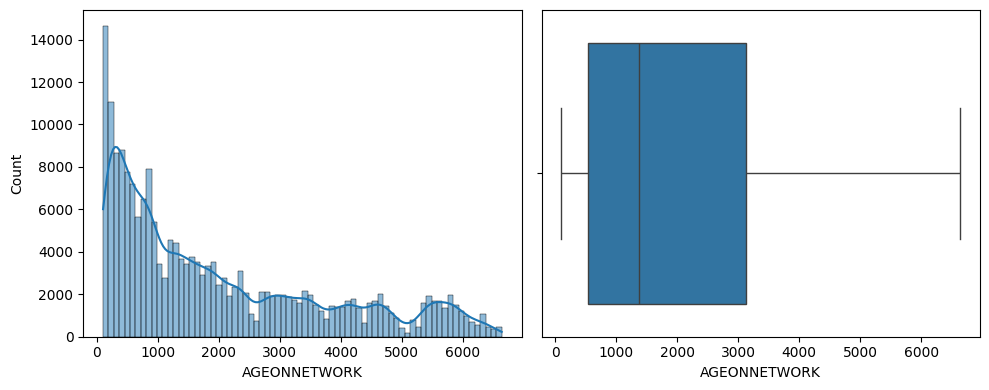

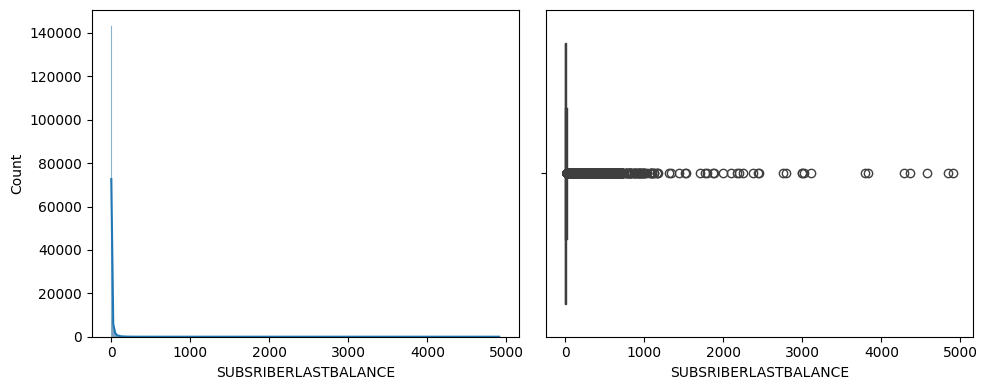

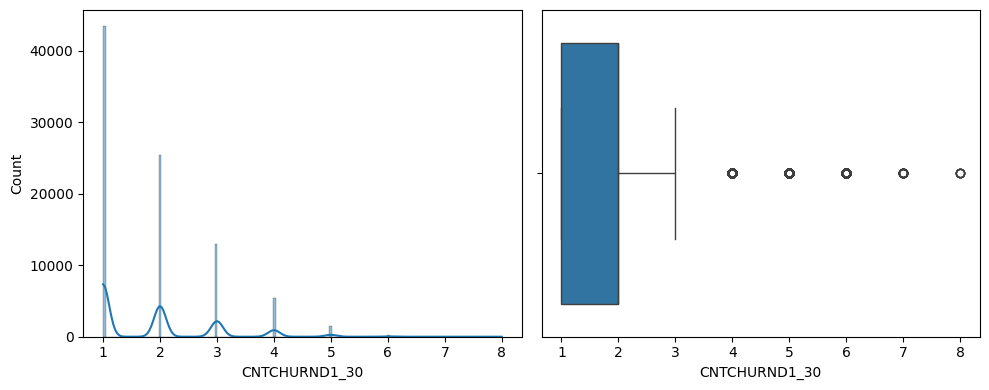

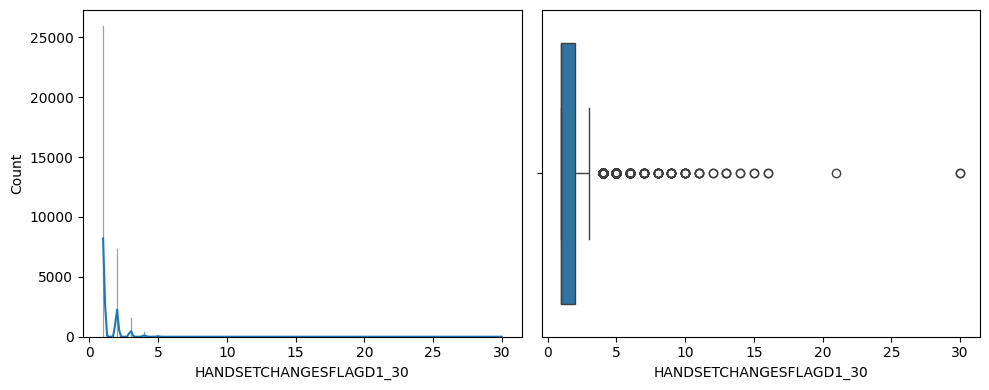

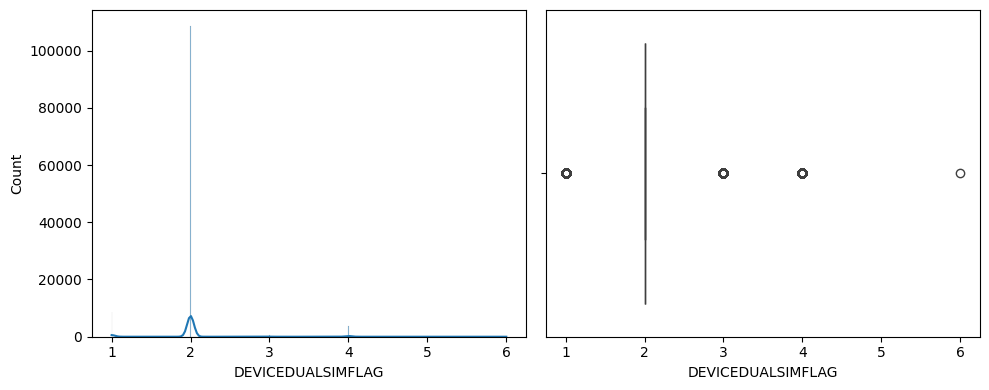

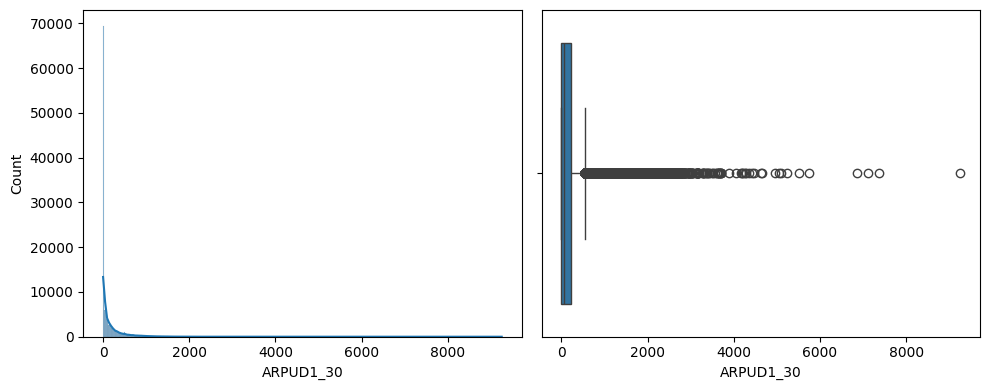

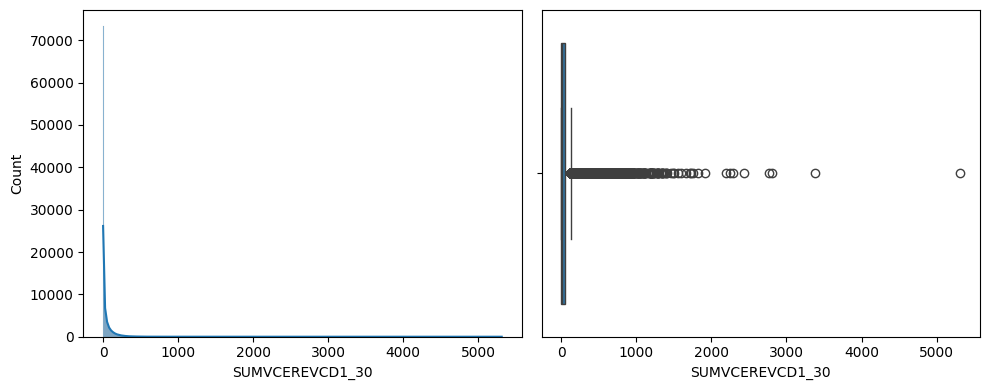

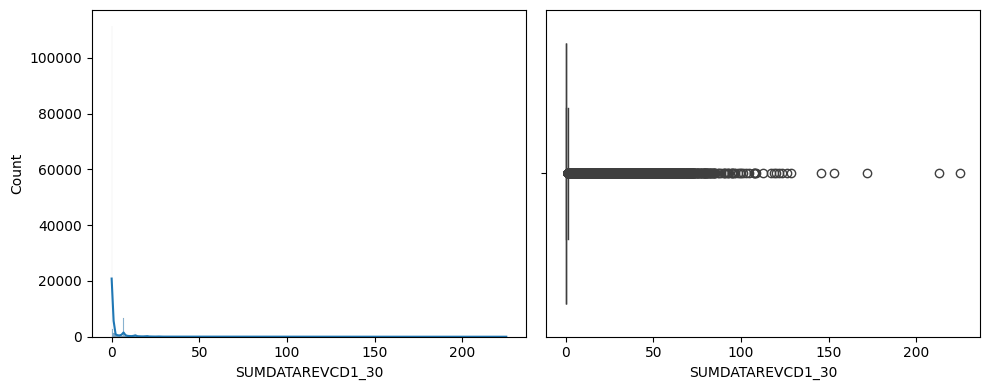

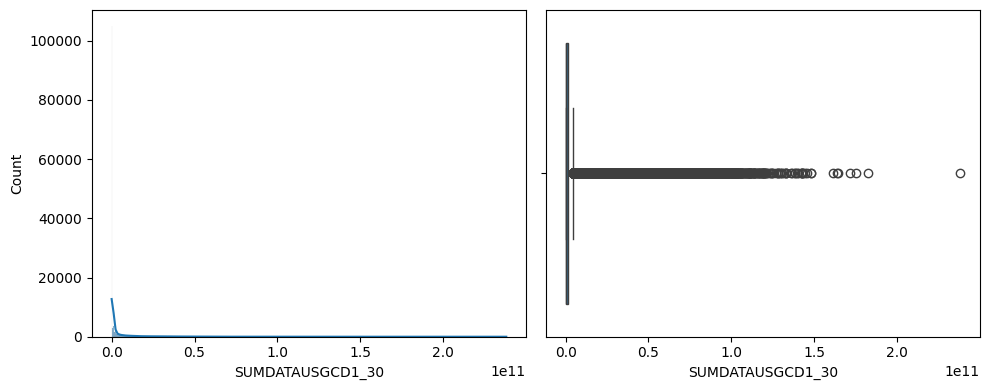

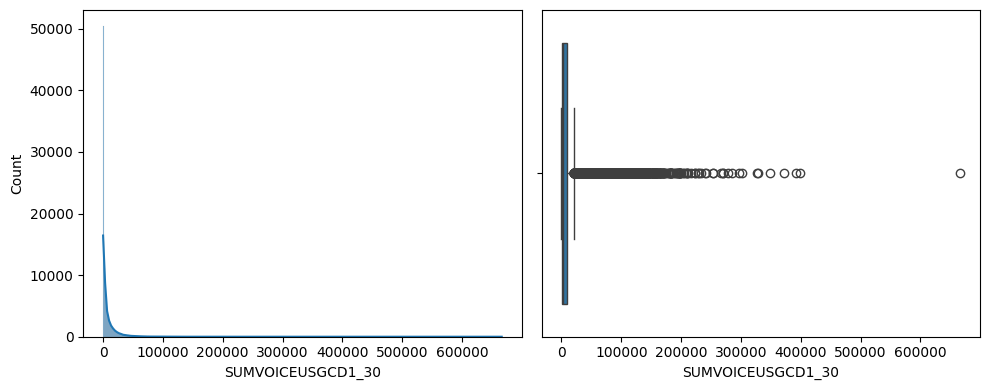

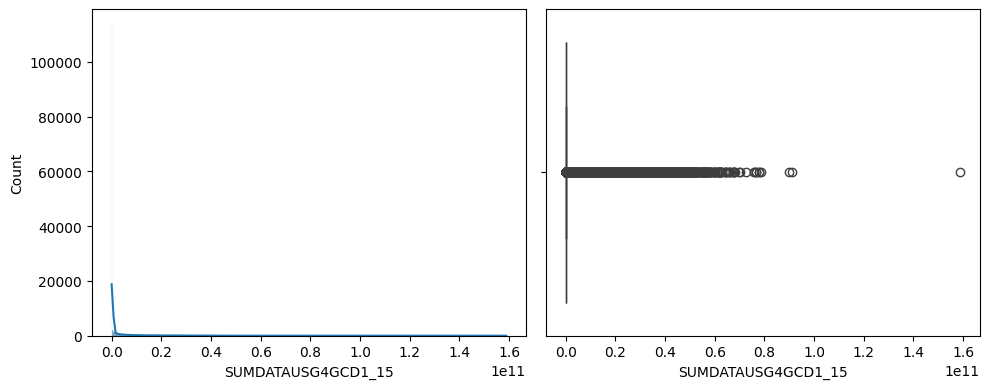

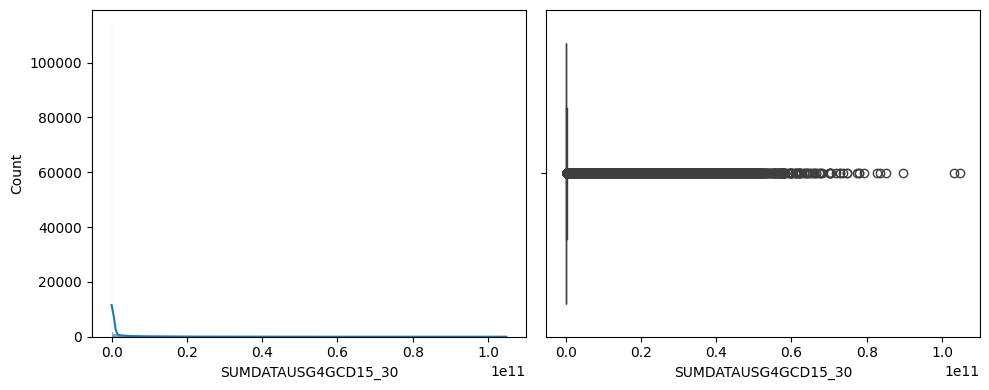

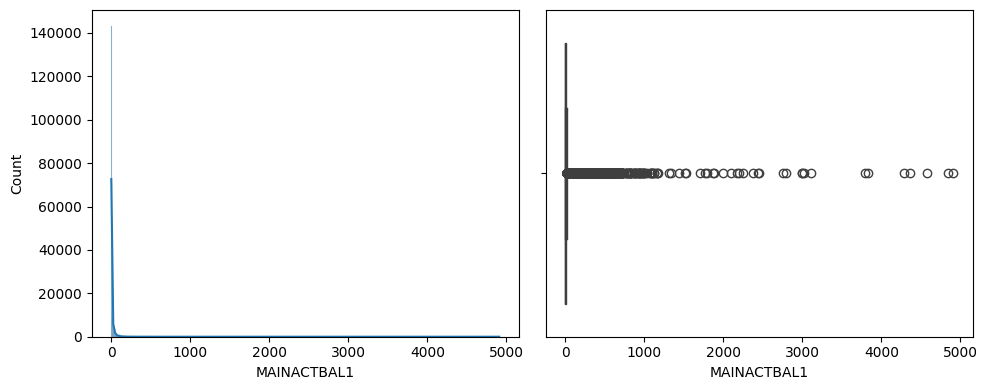

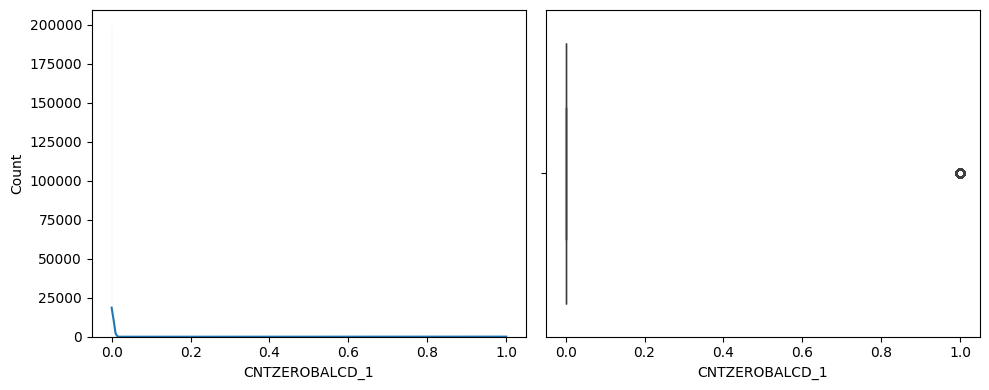

In [7]:
#For visualizing distributions
for col in data.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(data[col], kde=True)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[col])
    plt.tight_layout()
    plt.show()

In [8]:
#for Handling missing values
data = handle_missing_values(data)

c:\Users\paral\Documents\Customer Segmentation and Trageted Marketing for Telecom Operator\Notebooks\..\src\preprocessing.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
c:\Users\paral\Documents\Customer Segmentation and Trageted Marketing for Telecom Operator\Notebooks\..\src\preprocessing.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplac

In [10]:
#Dropping unnecessary columns
data.drop(columns=['Mobile_Number',
                   'MAINACTBAL',
                   'LASTVCEUSGDATE','LASTRECHRGDATE','FIRSTCALLDATE','LASTREVGENEVTDATE','FIRSTREVGENEVTDATE',
                   'CUSTSEGMENT',
                   'CNTZEROBALCD_1',
                   ],inplace=True)

In [11]:
# Saving cleaned data
data.to_csv('../Data/cleaned_data.csv', index=False)